In [1]:
!pip install pandas matplotlib seaborn xlrd openpyxl



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# CodeAlpha Task 3: Data Visualization

## Superstore Sales Analysis

### Objective
The objective of this project is to transform the Superstore sales data into meaningful visualizations using Python. The analysis focuses on understanding sales performance across categories, regions, segments, and time periods.

### Tools and Libraries
- Python
- Pandas
- Matplotlib
- Seaborn

### Key Questions
1. Which product categories generate the highest sales?
2. Which regions contribute the most to overall sales?
3. How do sales vary across customer segments?
4. How do sales change over time?
5. Which categories perform best in different regions?
6. What patterns and trends can be identified from the data?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Load the Superstore dataset
df = pd.read_excel("sample_-_superstore.xls")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 10194
Columns: 21


## 1. Understanding the Dataset

Before creating visualizations, we inspect the structure, columns, data types, and missing values in the dataset.

In [3]:
# Display the first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [5]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


## 2. Basic Sales Summary

We calculate basic sales statistics to understand the overall sales performance of the Superstore dataset.

In [6]:
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Average Sales per Order:", round(df["Sales"].mean(), 2))
print("Minimum Sales:", round(df["Sales"].min(), 2))
print("Maximum Sales:", round(df["Sales"].max(), 2))

Total Sales: 2326534.35
Average Sales per Order: 228.23
Minimum Sales: 0.44
Maximum Sales: 22638.48


## 3. Sales by Product Category

This visualization compares total sales across product categories and helps identify the strongest-performing categories.

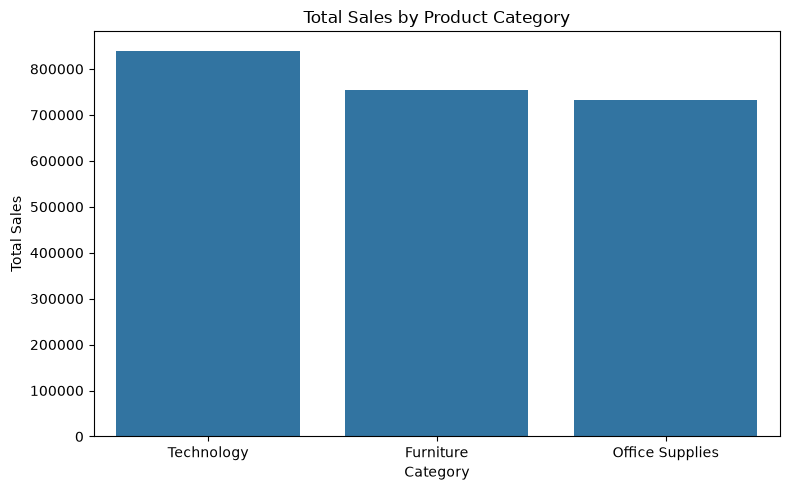

In [7]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("charts/sales_by_category.png", dpi=300)
plt.show()

### Insight

The category with the highest total sales represents the strongest contributor to overall revenue. Comparing categories helps identify which product areas have the greatest sales potential.

## 4. Sales by Region

This visualization compares total sales across different regions to identify the strongest geographical markets.

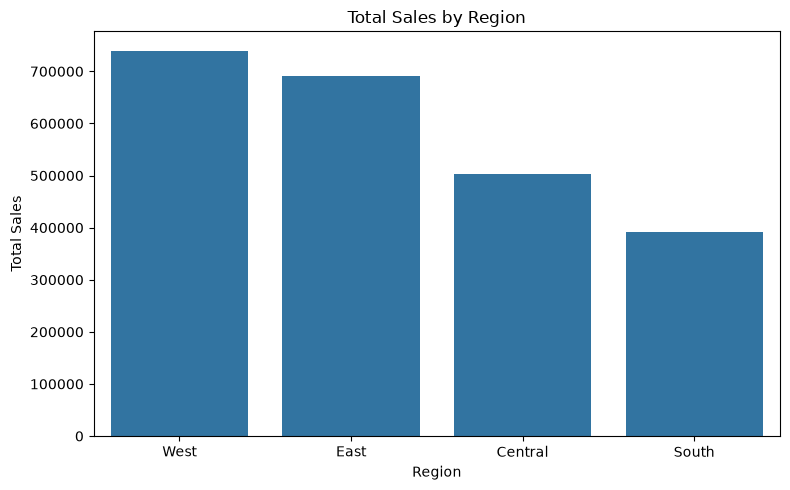

In [8]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("charts/sales_by_region.png", dpi=300)
plt.show()

### Insight

The regional comparison shows which geographical areas contribute most to total sales. This can help businesses identify high-performing markets and areas that may need additional attention.

## 5. Sales by Customer Segment

This visualization examines sales generated by different customer segments.

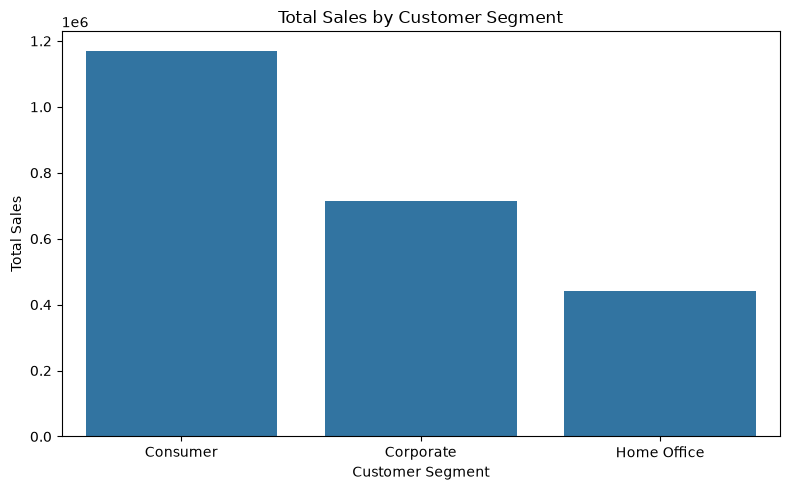

In [9]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_sales.index, y=segment_sales.values)
plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("charts/sales_by_segment.png", dpi=300)
plt.show()

### Insight

The customer segment comparison highlights which type of customers generates the highest sales and helps understand the importance of different customer groups.

## 6. Monthly Sales Trend

A time-series visualization is used to understand how sales change throughout the year.

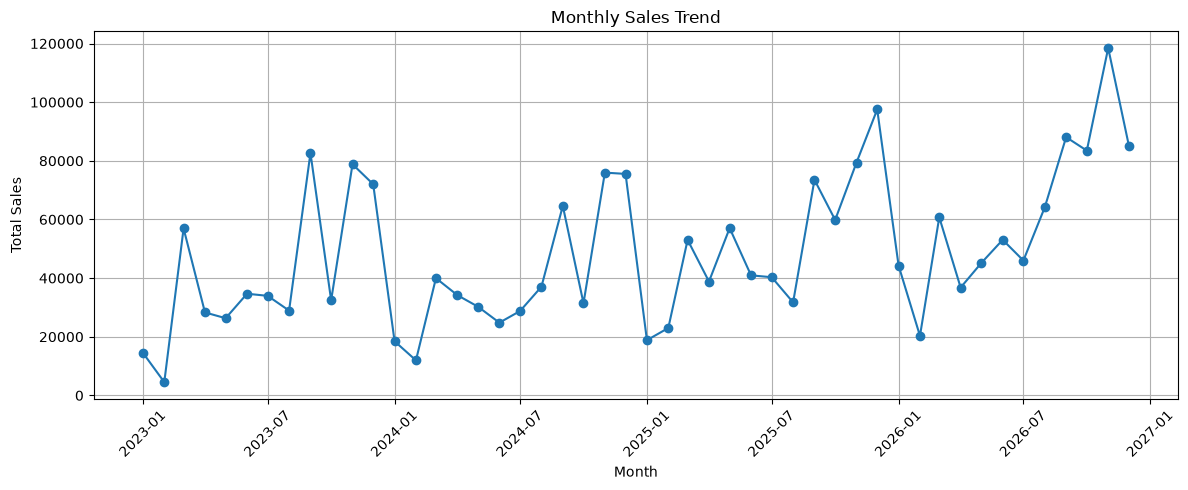

In [10]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Calculate monthly sales
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("charts/monthly_sales.png", dpi=300)
plt.show()

### Insight

The monthly sales trend shows how sales fluctuate over time. Peaks may indicate periods of stronger demand, while lower points may indicate slower sales periods.

## 7. Category Performance Across Regions

A heatmap is used to compare category sales across different regions.

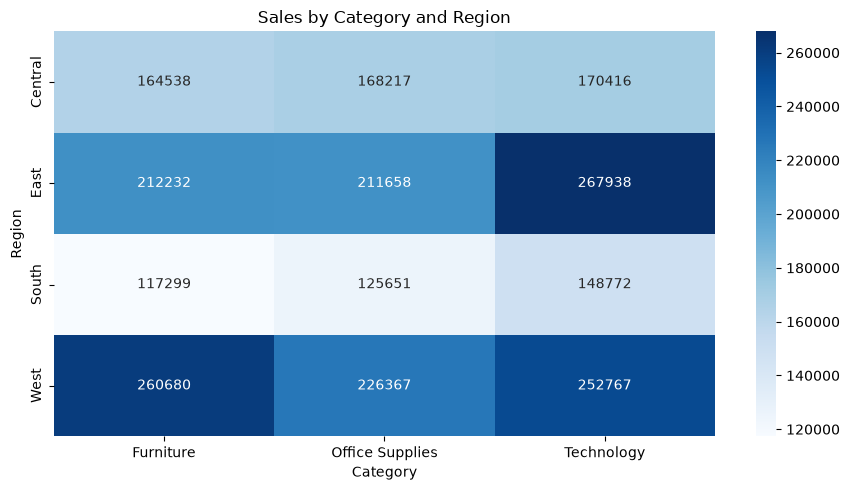

In [11]:
category_region = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

plt.figure(figsize=(9, 5))
sns.heatmap(category_region, annot=True, fmt=".0f", cmap="Blues")
plt.title("Sales by Category and Region")
plt.xlabel("Category")
plt.ylabel("Region")
plt.tight_layout()

plt.savefig("charts/category_region_heatmap.png", dpi=300)
plt.show()

### Insight

The heatmap makes it easier to compare category performance across regions and identify combinations of regions and categories with particularly strong sales.

## 8. Sales Distribution

A histogram is used to understand the distribution of individual order sales.

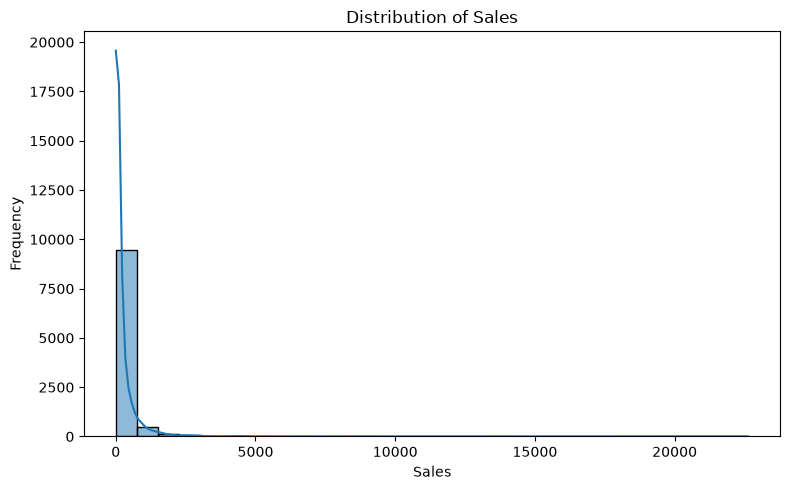

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], bins=30, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("charts/sales_distribution.png", dpi=300)
plt.show()

## 9. Key Findings

Based on the visual analysis:

- Sales performance varies across product categories.
- Different regions contribute differently to overall sales.
- Customer segments have different levels of sales contribution.
- Monthly sales show fluctuations over time.
- The category-region heatmap helps identify strong-performing combinations.
- The sales distribution shows how individual order values are spread across the dataset.

### Conclusion

Data visualization makes it easier to identify patterns, trends, and differences within the Superstore dataset. The visual insights can support business decisions related to products, regions, customers, and sales performance.

In [13]:
pd.read_excel("sample_-_superstore.xls")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,2026-12-30,2027-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,2026-12-30,2027-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279


## 2. Sales by Product Category

This visualization compares total sales across product categories and helps identify the strongest-performing categories.

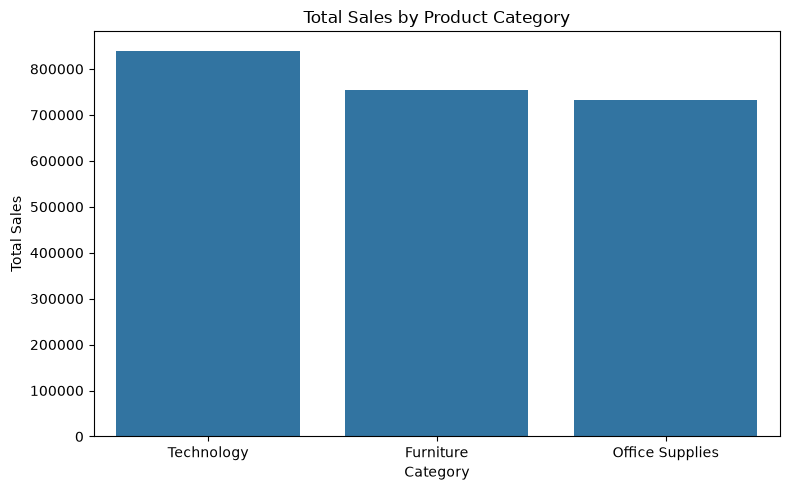

In [14]:
# Calculate total sales by category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()

# Save the chart
plt.savefig("charts/sales_by_category.png", dpi=300)

plt.show()